In [ ]:

# Standard Dependencies
import io, zipfile, tempfile, os, requests # IO - reaading/writing data, zipfile - zips data, tempfile - creates temporary files in memory, os - allows interaction with operating system, requests - handles API calls

# matplotlib Dependencies
import matplotlib.pyplot as plt # How we will create the figures
from matplotlib import ticker
from matplotlib.colors import LogNorm, PowerNorm, Normalize



# Data Handling Dependencies
import geopandas as gpd # Tells python how to deal with geographic data
import pandas as pd # Allows us to deal with generic datasets (this is what we do most often use in empiric work)



These are the only two things you really need -- GET ACS data contacts the ACS api at the census, and the get shape files contacts the census TIGER shape files. The rest is only for showing how to use these

In [ ]:
def get_acs_data(state_codes: str|list[str], variables: str|list[str], counties: list[str] = None, verbose = False, suffix:str =None) -> pd.DataFrame:
    """Get the ACS data from the Census API and return it as a Data Frame"""
    
    # Format the variables for API call
    VARIABLES = ",".join(variables) if isinstance(variables, list) else variables
    STATE_CODES = ",".join(state_codes) if isinstance(state_codes, list) else state_codes
    if counties is not None: 
        COUNTIES = ",".join(counties) if isinstance(counties, list) else counties
    else: 
        COUNTIES = "*"
    
    if suffix is not None: 
        suffix = f"/{suffix}"
    else:
        suffix = ""
        
    ACS_URL = (
        f"https://api.census.gov/data/2023/acs/acs5{suffix}"
        f"?get=NAME,{VARIABLES}" # Get just the Total Population variable (B01003_001E)
        f"&for=county:{COUNTIES}" # Get specified counties or all if None
        f"&in=state:{STATE_CODES}"  # GA state code is 13
    )
    r = requests.get(ACS_URL)
    r.raise_for_status()
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    del r, data # Clean up memory
    df.columns = df.columns.str.upper()

    non_numeric_cols = ['NAME','STATE','COUNTY']
    for col in df.columns:
        if col not in non_numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['GEOID'] = df['STATE'] + df['COUNTY']
    df = df[['GEOID', *[col for col in df.columns if col not in non_numeric_cols + ['GEOID']]]]
    return df

def get_shape_files(state_codes: str|list[str]):
    """Get the shape files from the TIGER URL and return it as a GeoDataFrame"""
    TIGER_URL = (
        "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
    )
    r = requests.get(TIGER_URL)
    r.raise_for_status()
    with tempfile.TemporaryDirectory() as tmp: 
        zip_path = os.path.join(tmp, "counties.zip")
        with open(zip_path, "wb") as f:
            f.write(r.content)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(tmp)
        # The shapefile lives directly in the tmp after extraction, so we can read it directly
        shp_file = [f for f in os.listdir(tmp) if f.endswith(".shp")][0]
        counties = gpd.read_file(os.path.join(tmp, shp_file))
    shape_df = counties[counties['STATEFP'].isin(state_codes)].copy() # Subset to just specified states
    del r, zip_path, shp_file, counties # Clean up memory
    return shape_df



In [ ]:
# DIAGNOSTIC MAP DRAWING FUNCTIONS: USED FOR QUICK DRAWING TO INVESTIGATE THE APPEARANCE OF THE DATA.

# Quickly draw a default map, no labels, no nonsense. Simple call. Just data, variable is all it needs!
def default_map(data, variable, cmap="Blues",
                linewidth=0.4, edgecolor='0.8', legend=True, norm=None, gamma = 0.3,  **legend_kwargs):
    """Create a default map with the specified variable and colormap
    """
    fig, ax = plt.subplots(1,1,figsize=(10,10))
    if norm is not None: 
        vmin, vmax = data[variable].min(), data[variable].max()
        # I personall don't recommend Symmetric Log or Arbitrary breakpoints (unless you have something like an explicit policy intervention you want to map). They are kind of arbitrary and can be misleading 
        # Here is a quick comparison 
        if norm == "linear":
            norm = Normalize(vmin=vmin, vmax=vmax)
        elif norm == "log":
            norm = LogNorm(vmin=vmin, vmax=vmax)
        elif norm == "power":
            norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
    data.plot(
        column = variable, 
        cmap = cmap, 
        norm = norm,
        linewidth = linewidth, 
        edgecolor = edgecolor,
        legend=legend,
        legend_kwds={
            **legend_kwargs,
            "orientation":"horizontal",
            "shrink":0.6, 
            "pad":0.02,
            "format":ticker.FuncFormatter(lambda x, pos: f"{int(x):,.0f}") # Format the legend labels with commas
        },
        ax=ax
    )
    ax.axis("off")
    plt.tight_layout()
    return plt

def different_norms(data, variable,cmap="Blues", var_name = "",
                linewidth=0.4, edgecolor='0.8', legend=True):
    vmin, vmax = data[variable].min(), data[variable].max()
    # I personall don't recommend Symmetric Log or Arbitrary breakpoints (unless you have something like an explicit policy intervention you want to map). They are kind of arbitrary and can be misleading 
    # Here is a quick comparison 

    norms = [
        ("Linear", Normalize(vmin=vmin, vmax=vmax)),
        ("Log", LogNorm(vmin=vmin, vmax=vmax)),
        ("Power (γ=0.3)", PowerNorm(gamma=0.3, vmin=vmin, vmax=vmax)),
    ]

    # Three side by side figures (compare to the single figure above) 
    fig, axes = plt.subplots(1,3,figsize=(24,8))
    for ax, (label,norm) in zip(axes, norms):
        data.plot(
            column=variable,
            cmap=cmap, 
            norm = norm, 
            linewidth=linewidth,
            edgecolor=edgecolor,
            legend=legend,
            legend_kwds={
                "label":var_name,
                "orientation":"horizontal",
                "shrink":0.8,
                "pad":0.02,
                "format":ticker.FuncFormatter(lambda x, pos: f"{int(x):,.0f}") # Format the legend labels with commas
            },
            ax=ax,
        )
        ax.set_title(label, fontsize=14, fontweight="bold")
        ax.axis('off')
    plt.tight_layout()
    return plt

def different_gammas(data, variable,cmap="Blues", var_name = "",
                linewidth=0.4, edgecolor='0.8', legend=True):
    vmin, vmax = data[variable].min(), data[variable].max()
    gammas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    fig, axes = plt.subplots(1,len(gammas),figsize=(5*len(gammas),8))
    for ax, gamma in zip(axes, gammas):
        norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
        data.plot(
            column=variable,
            cmap=cmap, 
            norm = norm, 
            linewidth=linewidth,
            edgecolor=edgecolor,
            legend=legend,
            legend_kwds={
                "label":var_name,
                "orientation":"horizontal",
                "shrink":0.8,
                "pad":0.02,
                "format":ticker.FuncFormatter(lambda x, pos: f"{int(x):,.0f}") # Format the legend labels with commas
            },
            ax=ax,
        )
        ax.set_title(f"Power Norm (γ={gamma})", fontsize=14, fontweight="bold")
        ax.axis('off')
    plt.tight_layout()
    return plt

def different_colors(data, variable, cmap="Blues",
                linewidth=0.4, edgecolor='0.8', legend=True, norm=None, gamma = 0.3,  **legend_kwargs):
    colors =['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn', 'binary', 'gist_yarg', 'gist_gray', 'gray', 'bone',
                      'pink', 'spring', 'summer', 'autumn', 'winter', 'cool',
                      'Wistia', 'hot', 'afmhot', 'gist_heat', 'copper', 'Pastel1', 'Pastel2', 'Paired', 'Accent', 'Dark2',
                      'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b',
                      'tab20c']
    fig, axes = plt.subplots(7,7,figsize=(35,35))
    for ax, color in zip(axes.flatten(), colors):
        data.plot(
            column = variable, 
            cmap = color, 
            norm = norm,
            linewidth = linewidth, 
            edgecolor = edgecolor,
            legend=legend,
            legend_kwds={
                **legend_kwargs,
                "orientation":"horizontal",
                "label":color,
                "shrink":0.6, 
                "pad":0.02,
                "format":ticker.FuncFormatter(lambda x, pos: f"{int(x):,.0f}") # Format the legend labels with commas
            },
            ax=ax
        )
        ax.set_title(color, fontsize=14, fontweight="bold")
        ax.axis("off")
    plt.tight_layout()
    return plt

In [ ]:
state_codes = ['01','12','13','47','28','22'] # Can find the tables at  https://www2.census.gov/geo/docs/reference/codes2020/national_state2020.txt # 13 is Georgia
population_data = get_shape_files(state_codes=state_codes)[['GEOID', 'geometry']].merge(
    get_acs_data(state_codes=state_codes, variables=["B01003_001E"]),
    on='GEOID',
    how='inner'
)

laborforce_data = get_shape_files(state_codes=state_codes)[['GEOID', 'geometry']].merge(
    get_acs_data(state_codes=state_codes, variables=["DP03_0002PE"], suffix ="profile"),
    on='GEOID',
    how='inner'
)

# Testing Different Maps

I have built in 4 functions to try and help users better pick colors, normalizers, etc. 

* default_map() creates a default, single pane map with no labels, this is not production redy, one should write their own code to ensure quality aspects. 
* different_norms() creates 3 figures, one for each of the different types of normalizations (linear, log, gamma(0.3))
* different_gammas() creates 10 figures with 0.1 step increments to the gamma normalizer to help users better pick out norm and gamma
* different_colors() produces 46 figures using most of the available color specturms (omitting diverging palettes) from matplotlib. 

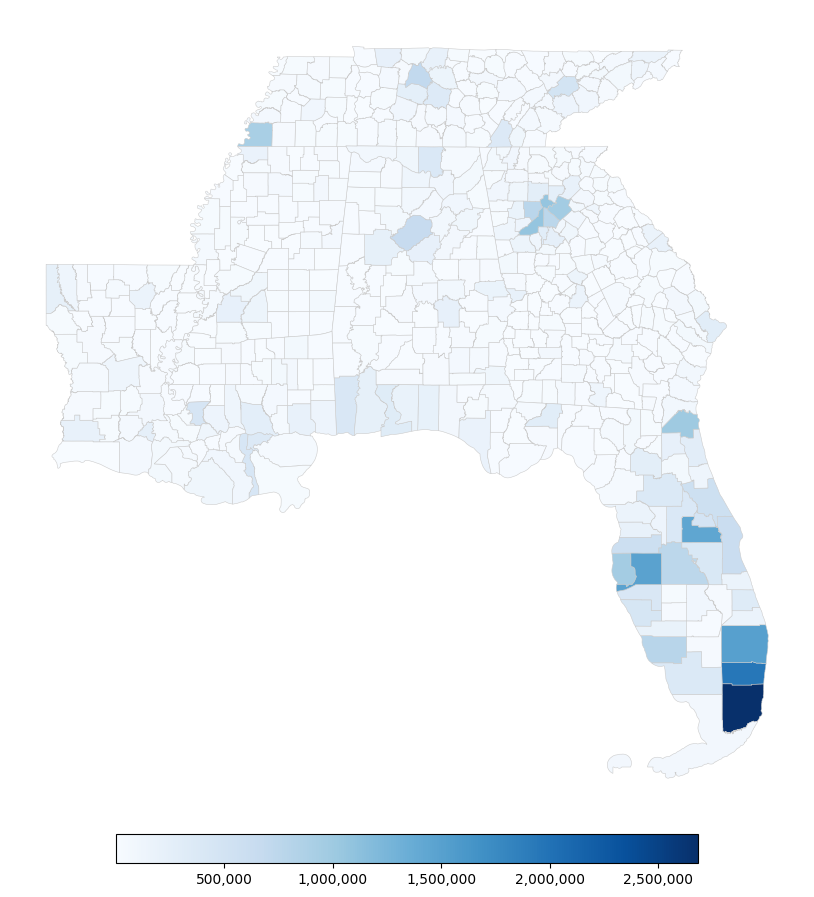

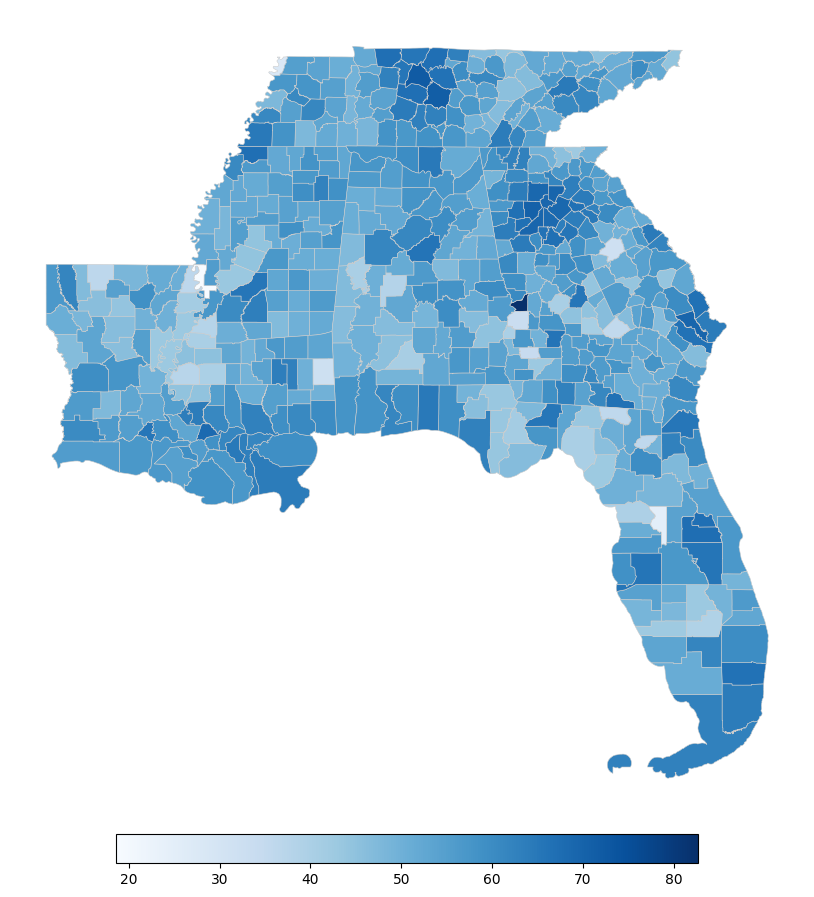

In [8]:
default_map(population_data, 'B01003_001E', cmap="Blues").show()   # Default Map is for quick tests of things, checking out, not for final products. For final products, actually just write your own preferences into it. 
default_map(laborforce_data, 'DP03_0002PE', cmap="Blues").show()   # Default Map is for quick tests of things, checking out, not for final products. For final products, actually just write your own preferences into it. 

/tmp/ipykernel_6434/1074277003.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = columbus_annotation.geometry.centroid.iloc[0]


<function matplotlib.pyplot.show(close=None, block=None)>

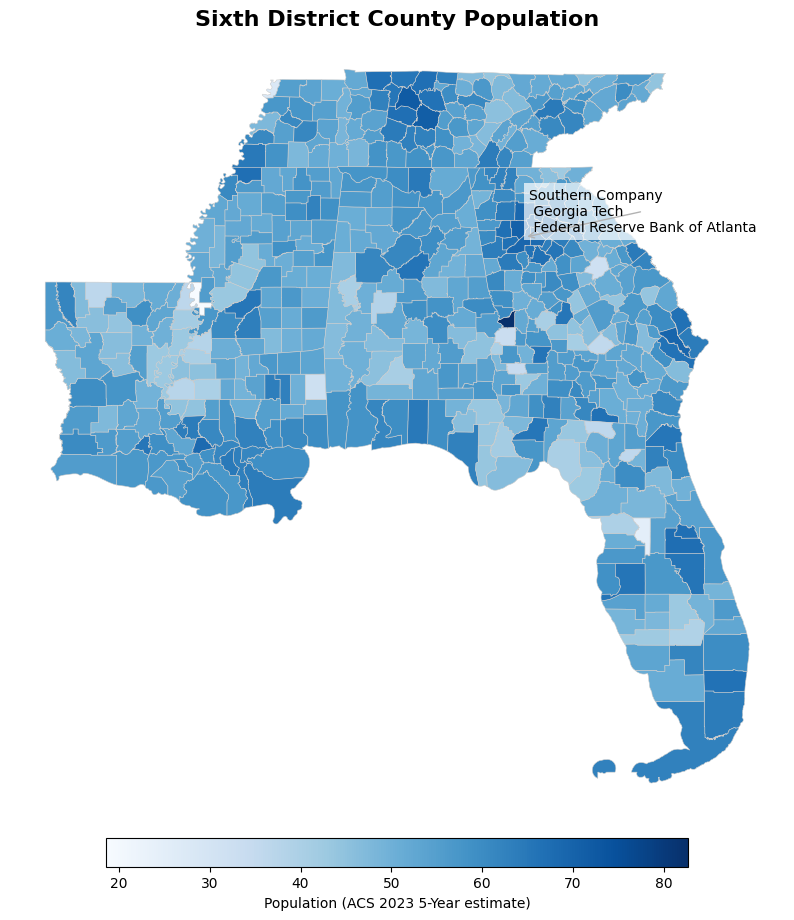

In [17]:
fig, ax = plt.subplots(1,1,figsize=(10,10))


laborforce_data.plot(
    column='DP03_0002PE',
    cmap="Blues", 
    linewidth=0.4,
    edgecolor='0.8',
    legend=True,
    legend_kwds={
        "label":"Population (ACS 2023 5-Year estimate)",
        "orientation":"horizontal",
        "shrink":0.6,
        "pad":0.02,
        "format":ticker.FuncFormatter(lambda x, pos: f"{int(x):,.0f}") # Format the legend labels with commas
    },
    ax=ax,
)
columbus_annotation =laborforce_data[laborforce_data["GEOID"] =="13121"]
# columbus_annotation.plot(ax=ax, color="orange", edgecolor="red", linewidth=1.5) THIS HIGHLIGHTS IF YOU WANT THAT
centroid = columbus_annotation.geometry.centroid.iloc[0]
ax.annotate(
    f"Southern Company \n Georgia Tech\n Federal Reserve Bank of Atlanta",
    xy=(centroid.x, centroid.y),
    xytext=(centroid.x + 0.1, centroid.y + 0.1),  # Offset text
    arrowprops=dict(facecolor="black", arrowstyle="->"),
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

ax.set_title("Sixth District County Population", fontsize=16, fontweight="bold")
ax.axis('off')
plt.tight_layout()
plt.savefig("Sixth District Population Map.png", dpi=300)
plt.show



In [9]:
"""
different_norms(map_data, variable='B01003_001E').show()    # The different norms function is for comparing the linear, log, and power (0.3) normalizations side-by-side
different_gammas(map_data, variable='B01003_001E', cmap="spring").show()   # The different gammas function is for comparing different power normalizations, which can be useful if you want to use a power norm but aren't sure which gamma to use.
different_colors(map_data, variable='B01003_001E').show()    # The different norms function is for comparing the 46 available color palettes with your specific data.
"""

'\ndifferent_norms(map_data, variable=\'B01003_001E\').show()    # The different norms function is for comparing the linear, log, and power (0.3) normalizations side-by-side\ndifferent_gammas(map_data, variable=\'B01003_001E\', cmap="spring").show()   # The different gammas function is for comparing different power normalizations, which can be useful if you want to use a power norm but aren\'t sure which gamma to use.\ndifferent_colors(map_data, variable=\'B01003_001E\').show()    # The different norms function is for comparing the 46 available color palettes with your specific data.\n'